<a href="https://colab.research.google.com/github/Mosizamani/AAI-521/blob/main/Module1_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Enbleing GPU

In [2]:
import tensorflow as tf
print(tf.version.VERSION)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

2.19.0
Found GPU at: /device:GPU:0


## Let's examine these images

These are the available classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


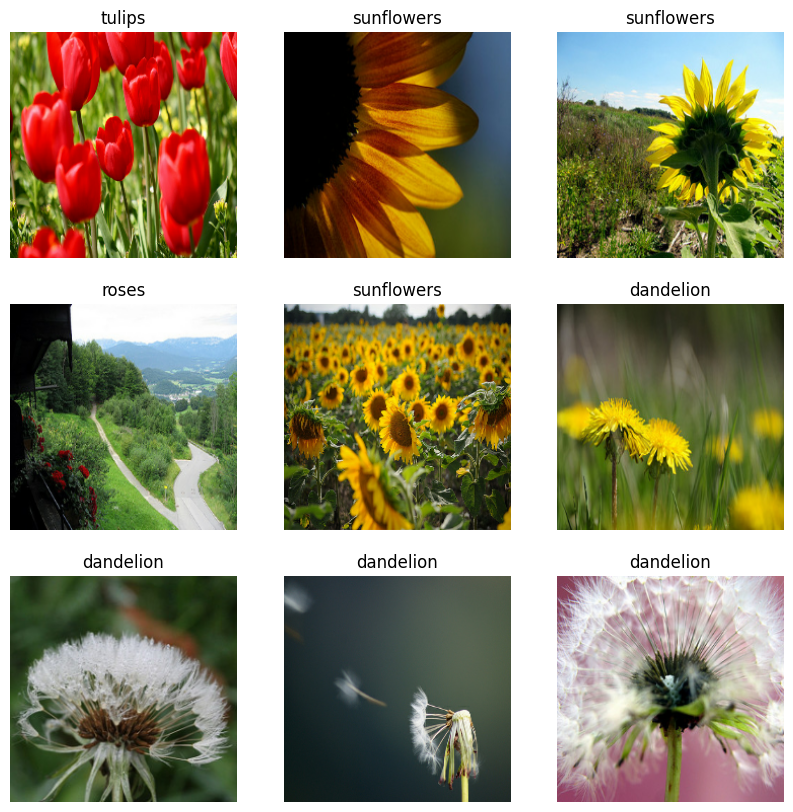

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

# Image parameters
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

# Load TensorFlow's built-in flower dataset
(ds_train, ds_test), ds_info = tfds.load(
    "tf_flowers",
    split=["train[:85%]", "train[85%:]"],  # split train/test
    as_supervised=True,  # returns (image, label)
    with_info=True
)

# Class names
CLASS_NAMES = ds_info.features["label"].names
print("These are the available classes:", CLASS_NAMES)

# Preprocessing function
def preprocess(image, label):
    # Resize and normalize the image
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Apply preprocessing and batching
BATCH_SIZE = 10
train_dataset = ds_train.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = ds_test.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Show a few sample images
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(CLASS_NAMES[labels[i]])
        plt.axis("off")
plt.show()